In [1]:
#-- 기본 설정 + DB 연결 + 데이터 범위 확인

import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt

# 현재 작업 경로 확인
print("현재 작업 폴더:", os.getcwd())

# DB 연결
conn = sqlite3.connect("../db/olist.db")

# 주문 데이터 범위 확인
print(pd.read_sql("""
SELECT
    MIN(order_purchase_timestamp) AS first_order,
    MAX(order_purchase_timestamp) AS last_order,
    COUNT(*) AS total_orders
FROM orders;
""", conn))

현재 작업 폴더: /Users/chaeyoung/Documents/GitHub/olist-ecommerce-analysis/notebooks
           first_order           last_order  total_orders
0  2016-09-04 21:15:19  2018-10-17 17:30:18         99441


  order_status  order_count  order_pct
0    delivered        96478      97.02
1      shipped         1107       1.11
2     canceled          625       0.63
3  unavailable          609       0.61
4     invoiced          314       0.32
5   processing          301       0.30
6      created            5       0.01
7     approved            2       0.00


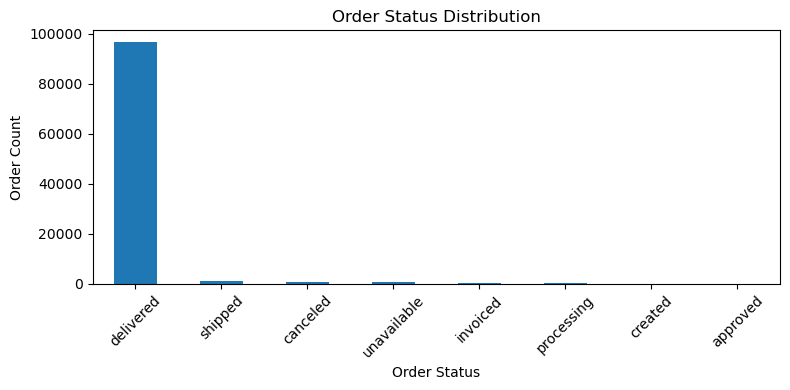

In [2]:
#- 주문 상태 분포 확인

# 주문 상태별 건수 / 비율 확인
order_status = pd.read_sql("""
SELECT
    order_status,
    COUNT(*) AS order_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) AS order_pct
FROM orders
GROUP BY order_status
ORDER BY order_count DESC;
""", conn)

print(order_status)

# 시각화
order_status.plot(
    kind="bar",
    x="order_status",
    y="order_count",
    figsize=(8, 4),
    legend=False
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

  order_month  order_count    revenue     aov
0     2016-09            3     252.24   84.08
1     2016-10          324   59090.48  182.38
2     2016-12            1      19.62   19.62
3     2017-01          800  138488.04  173.11
4     2017-02         1780  291908.01  163.99


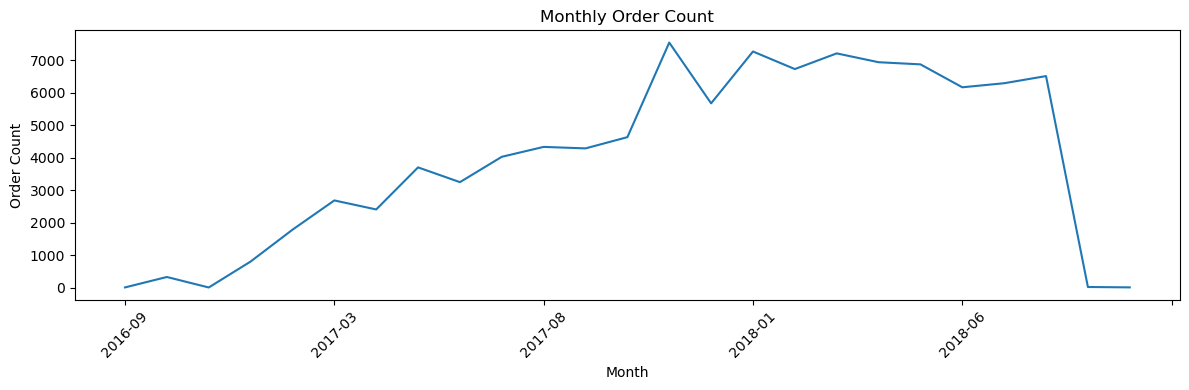

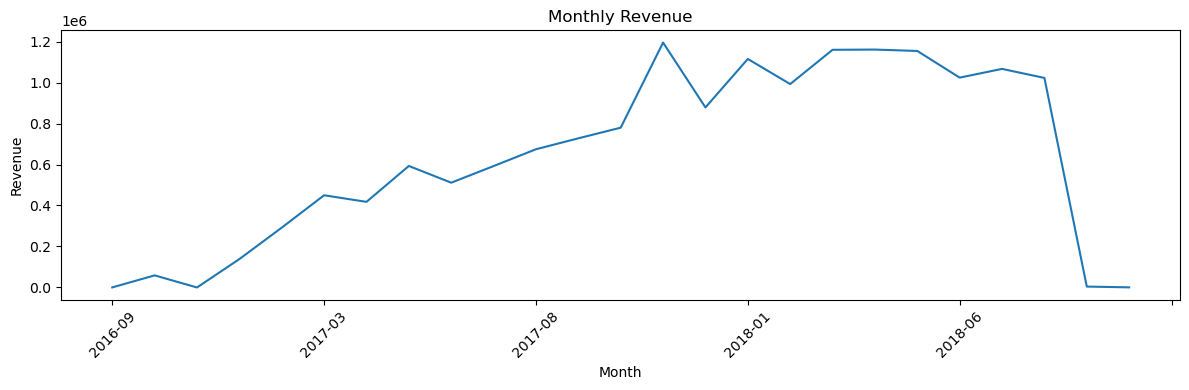

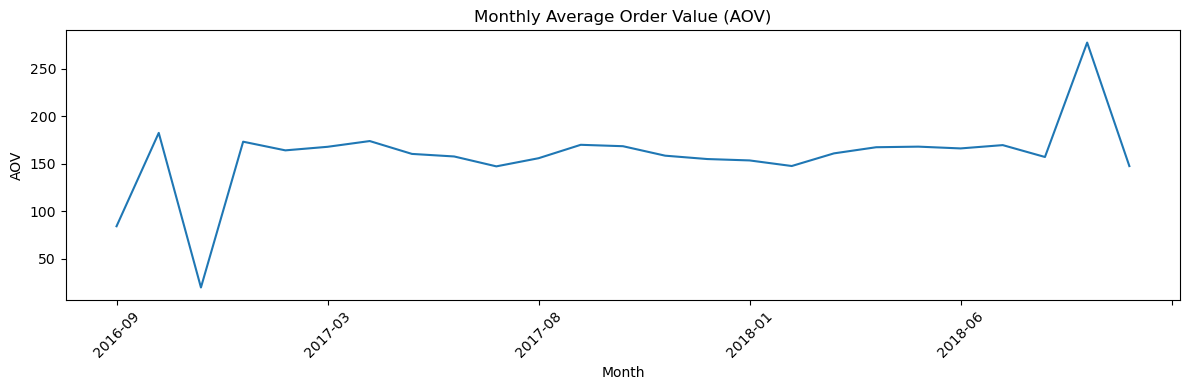

In [3]:
# - 3) 월별 주문 수 / 매출 / 평균 주문금액(AOV) 분석

# 월별 주문 수 / 매출 / 평균 주문금액(AOV) 계산
monthly_summary = pd.read_sql("""
WITH payment_per_order AS (
    SELECT
        order_id,
        SUM(payment_value) AS total_payment
    FROM order_payments
    GROUP BY order_id
)
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
    COUNT(DISTINCT o.order_id) AS order_count,
    ROUND(SUM(p.total_payment), 2) AS revenue,
    ROUND(SUM(p.total_payment) * 1.0 / COUNT(DISTINCT o.order_id), 2) AS aov
FROM orders o
JOIN payment_per_order p
    ON o.order_id = p.order_id
GROUP BY order_month
ORDER BY order_month;
""", conn)

print(monthly_summary.head())

# 월별 주문 수 추이
monthly_summary.plot(
    x="order_month",
    y="order_count",
    figsize=(12, 4),
    legend=False
)

plt.title("Monthly Order Count")
plt.xlabel("Month")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 월별 매출 추이
monthly_summary.plot(
    x="order_month",
    y="revenue",
    figsize=(12, 4),
    legend=False
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 월별 평균 주문금액(AOV) 추이
monthly_summary.plot(
    x="order_month",
    y="aov",
    figsize=(12, 4),
    legend=False
)

plt.title("Monthly Average Order Value (AOV)")
plt.xlabel("Month")
plt.ylabel("AOV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# 최종 요약 테이블
# 전체 주문 / 완료 주문 / 취소 주문 / 총매출 / 평균 주문금액 요약
summary_table = pd.read_sql("""
WITH payment_per_order AS (
    SELECT
        order_id,
        SUM(payment_value) AS total_payment
    FROM order_payments
    GROUP BY order_id
)
SELECT
    COUNT(DISTINCT o.order_id) AS total_orders,
    SUM(CASE WHEN o.order_status = 'delivered' THEN 1 ELSE 0 END) AS delivered_orders,
    SUM(CASE WHEN o.order_status = 'canceled' THEN 1 ELSE 0 END) AS canceled_orders,
    ROUND(SUM(p.total_payment), 2) AS total_revenue,
    ROUND(SUM(p.total_payment) * 1.0 / COUNT(DISTINCT o.order_id), 2) AS avg_order_value
FROM orders o
JOIN payment_per_order p
    ON o.order_id = p.order_id;
""", conn)

print(summary_table)

   total_orders  delivered_orders  canceled_orders  total_revenue  \
0         99440             96477              625    16008872.12   

   avg_order_value  
0           160.99  
